In [ ]:
import dataclasses
import logging
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Resolve project root regardless of where the notebook is launched from
for _candidate in [".", "..", "../.."]:  # noqa: B007
    _p = os.path.abspath(_candidate)
    if os.path.isdir(os.path.join(_p, "src")):
        sys.path.insert(0, _p)
        break

from sklearn.decomposition import PCA, FastICA  # noqa: E402

from scripts.analysis_common import (  # noqa: E402
    FREQUENCY_BANDS,
    _WAVELET_BAND_FREQ_RESOLUTION_HZ,
    _wavelet_transform,
    analyzers_to_datasets,
    load_analyzers,
)
from src.analysis.isc import compute_loo_isc  # noqa: E402
from src.definitions.constants import ProjectPaths  # noqa: E402
from src.definitions.fields import (  # noqa: E402
    ConditionVariants,
    ExclusionCategories,
    MusicTypeVariants,
)

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.0)
%matplotlib inline

# Super-Brain ICA / PCA on Wavelet Power

**Approach 1** — concatenate *person × channel × frequency* into features,
keep *time* as the observation axis.

```
(n_subjects, n_channels, n_freqs, n_times)
  → reshape →  (n_subjects × n_channels × n_freqs,  n_times)
```

PCA / ICA find a small set of **temporal components** whose loadings
can be decomposed back into subject, channel (spatial), and frequency
(spectral) weights.

**Analyses:**

1. PCA scree plot (variance explained)
2. Component time courses
3. Subject loadings per component
4. Channel loadings — topographic maps
5. Frequency loadings per component
6. Component power spectrogram (time–frequency view)
7. ISC of component time courses
8. Cross-component correlation matrix


## Configuration


In [ ]:
# ── Experiment configuration ─────────────────────────────────────────────────
CONDITION = ConditionVariants.PLACEBO
MUSIC_TYPES = [MusicTypeVariants.CLASSICAL]  # single type for fast exploration
EXCLUSION_CATEGORIES = [ExclusionCategories.BAD_MUSIC, ExclusionCategories.ARTIFACTS]
PROCESS_AND_SAVE_DATA = False  # set True to re-process raw files

# ── Wavelet settings ─────────────────────────────────────────────────────────
REPRESENTATION = "power"
WAVELET_FREQ_MIN = min(lo for lo, _ in FREQUENCY_BANDS.values())
WAVELET_FREQ_MAX = max(hi for _, hi in FREQUENCY_BANDS.values())
WAVELET_N_FREQS = max(
    2,
    int(round((WAVELET_FREQ_MAX - WAVELET_FREQ_MIN) / _WAVELET_BAND_FREQ_RESOLUTION_HZ))
    + 1,
)
FREQS = np.linspace(WAVELET_FREQ_MIN, WAVELET_FREQ_MAX, WAVELET_N_FREQS)

KEEP_FREQUENCY_DIM = True
RESHAPE_FREQUENCY_DIM = True  # -> (n_subjects, n_channels, n_freqs, n_times)

# ── Reuse / compute ──────────────────────────────────────────────────────────
REUSE_WAVELETS = True  # load from cache; set False to compute + save

# ── Subject subset ────────────────────────────────────────────────────────────
N_SUBJECTS_SUBSET: int | None = 5

# ── Channel and time subset ───────────────────────────────────────────────────
N_CHANNELS_SUBSET: int | None = 32  # first N channels (from 195)
N_TIMES_SUBSET: int | None = 10000  # first N time samples

# ── Decomposition settings ────────────────────────────────────────────────────
N_COMPONENTS_PCA = 20  # number of PCA components to retain
N_COMPONENTS_ICA = 10  # number of ICA components to extract
ICA_RANDOM_STATE = 42  # reproducibility

# ── Storage directory ─────────────────────────────────────────────────────────
WAVELET_DIR: Path = (
    ProjectPaths.NOTEBOOKS_DIR / "04-wavelet-ica-analysis" / "wavelet_cache"
)

# ── Plot saving ──────────────────────────────────────────────────────────────
SAVE_PLOTS = True
PLOTS_DIR = (
    ProjectPaths.NOTEBOOKS_DIR / "04-wavelet-ica-analysis" / "plots" / "superbrain"
)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Wavelet base directory : {WAVELET_DIR}")
print(
    f"Frequencies            : {FREQS[0]:.1f}\u2013{FREQS[-1]:.1f} Hz ({len(FREQS)} steps)"
)
print(f"PCA components         : {N_COMPONENTS_PCA}")
print(f"ICA components         : {N_COMPONENTS_ICA}")

Wavelet base directory : /auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/notebooks/04-wavelet-ica-analysis/wavelet_cache
Frequencies            : 1.0–70.0 Hz (70 steps)
PCA components         : 20
ICA components         : 10


## Data Loading


In [ ]:
analyzers = load_analyzers(
    MUSIC_TYPES,
    CONDITION,
    EXCLUSION_CATEGORIES,
    PROCESS_AND_SAVE_DATA,
    normalize_data=False,
)
datasets = analyzers_to_datasets(analyzers)

# Always limit to first N_SUBJECTS_SUBSET individuals
if N_SUBJECTS_SUBSET is not None:
    datasets = {
        label: dataclasses.replace(ad, data=ad.data[:N_SUBJECTS_SUBSET])
        for label, ad in datasets.items()
    }
    print(f"Using first {N_SUBJECTS_SUBSET} individuals.")

# Slice to channel subset
if N_CHANNELS_SUBSET is not None:
    datasets = {
        label: dataclasses.replace(ad, data=ad.data[:, :N_CHANNELS_SUBSET, :])
        for label, ad in datasets.items()
    }
    print(f"Using first {N_CHANNELS_SUBSET} channels.")

# Slice to time subset
if N_TIMES_SUBSET is not None:
    datasets = {
        label: dataclasses.replace(ad, data=ad.data[:, :, :N_TIMES_SUBSET])
        for label, ad in datasets.items()
    }
    print(f"Using first {N_TIMES_SUBSET} time samples.")

print("Loaded datasets:", list(datasets.keys()))
for label, ad in datasets.items():
    print(
        f"  {label}: {ad.n_items} subjects, {ad.n_features} channels, "
        f"{ad.n_samples} samples"
    )

INFO src.analysis.summary.EEGSummarizedAnalyzer: Data loaded from /auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/data/processed/psilo_music/concatenated/Placebo_CLASSIC.npy  (shape=(15, 195, 91392))


Opening raw data file /auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/data/processed/psilo_music/cropped/PSI035_EEGB_MUSIC_CLASSIC_EC_20180209_124821.fif...
    Range : 19254 ... 384821 =     19.254 ...   384.821 secs
Ready.


/auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/src/io/loading.py:110: RuntimeWarning: This filename (/auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/data/processed/psilo_music/cropped/PSI035_EEGB_MUSIC_CLASSIC_EC_20180209_124821.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  return mne.io.read_raw_fif(
INFO scripts.analysis_common: [Placebo_CLASSIC] Loaded data shape: (15, 195, 91392)
INFO scripts.analysis_common: [Placebo_CLASSIC] AnalysisData('Placebo_CLASSIC', time_domain, 15 items × 195 features × 91392 samples, sfreq=250.0)


Using first 5 individuals.
Using first 32 channels.
Using first 10000 time samples.
Loaded datasets: ['Placebo_CLASSIC']
  Placebo_CLASSIC: 5 subjects, 32 channels, 10000 samples


## Load or Compute Wavelet Transforms

Stored in `WAVELET_DIR/broadband/`.


In [ ]:
broadband_datasets = _wavelet_transform(
    datasets=datasets,
    freqs=FREQS,
    representation=REPRESENTATION,
    keep_frequency_dim=KEEP_FREQUENCY_DIM,
    reshape_frequency_dim=RESHAPE_FREQUENCY_DIM,
    wavelet_dir=WAVELET_DIR / "broadband",
    reuse_wavelets=REUSE_WAVELETS,
)
for label, ad in broadband_datasets.items():
    source = ad.metadata.get("loaded_from_wavelet_file", "computed_now")
    print(f"[broadband] {label}: shape={ad.data.shape}  source={source}")

[broadband] Placebo_CLASSIC: shape=(5, 32, 70, 10000)  source=/auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/notebooks/04-wavelet-ica-analysis/wavelet_cache/broadband/Placebo_CLASSIC__wavelet_power__1.000_70.000_70__freqdim1.npz


## Dataset Selection

Change `LABEL` to switch between music types.  The remaining cells use
`bb_data` (broadband wavelet power, 4-D) and derived quantities.


In [ ]:
LABEL = list(broadband_datasets.keys())[0]

bb_ad = broadband_datasets[LABEL]
bb_data = bb_ad.data  # (n_subjects, n_channels, n_freqs, n_times)
sfreq = bb_ad.sfreq

n_subjects, n_channels, n_freqs, n_times = bb_data.shape
time = np.arange(n_times) / sfreq

print(f"Dataset    : {LABEL}")
print(
    f"Shape      : {bb_data.shape}  (subjects \u00d7 channels \u00d7 freqs \u00d7 times)"
)
print(f"Duration   : {n_times / sfreq:.1f} s  @  {sfreq} Hz")
print(f"Freq range : {FREQS[0]:.1f}\u2013{FREQS[-1]:.1f} Hz ({n_freqs} steps)")

Dataset    : Placebo_CLASSIC
Shape      : (5, 32, 70, 10000)  (subjects × channels × freqs × times)
Duration   : 40.0 s  @  250.0 Hz
Freq range : 1.0–70.0 Hz (70 steps)


## Super-Brain Reshape

Flatten `(n_subjects, n_channels, n_freqs)` into one feature axis.
The resulting matrix has shape `(n_subjects × n_channels × n_freqs, n_times)`.

Before decomposition we **z-score each feature** (row) across time so that
PCA/ICA are not dominated by high-amplitude features.


In [ ]:
# Reshape 4-D → 2-D:  (n_subjects * n_channels * n_freqs,  n_times)
X_super = bb_data.reshape(-1, n_times)  # (S*C*F, T)
print(f"Super-brain matrix shape: {X_super.shape}")

# Z-score each row (feature) across time
row_mean = X_super.mean(axis=1, keepdims=True)
row_std = X_super.std(axis=1, keepdims=True) + 1e-10
X_super_z = (X_super - row_mean) / row_std
print("Z-scored super-brain matrix ready.")

Super-brain matrix shape: (11200, 10000)
Z-scored super-brain matrix ready.


---
## 1 — PCA Scree Plot (Variance Explained)

Fit PCA to the super-brain matrix and plot the cumulative variance
explained by the first `N_COMPONENTS_PCA` components.  This reveals
how many independent temporal modes capture most of the signal.


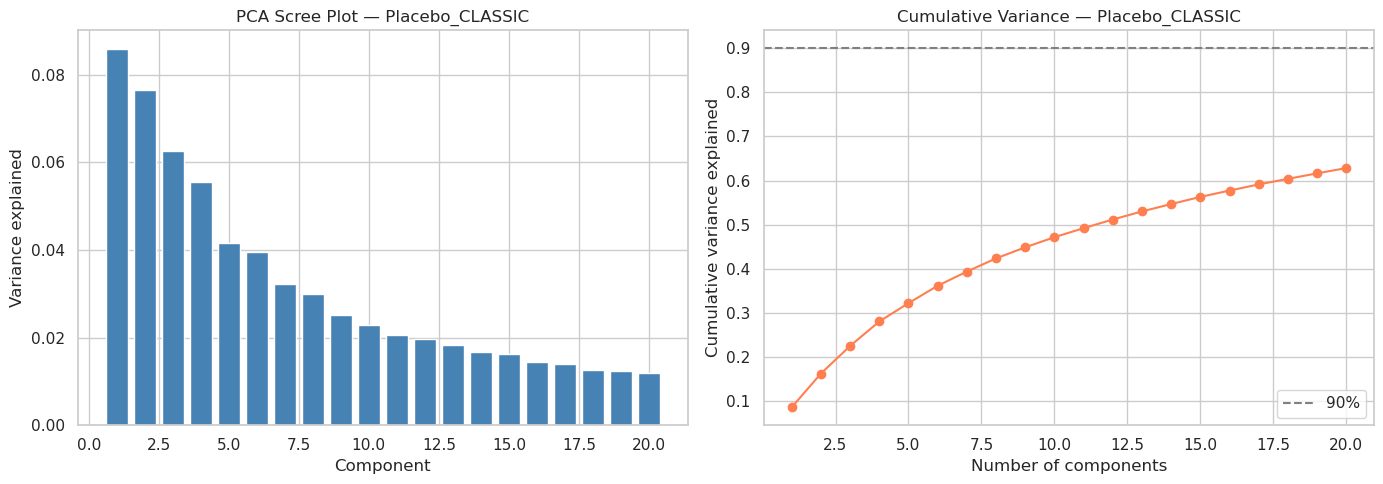

Top 20 components explain 62.8% of total variance.


In [ ]:
pca = PCA(n_components=N_COMPONENTS_PCA, random_state=ICA_RANDOM_STATE)
pca.fit(X_super_z.T)  # sklearn expects (n_samples, n_features) → (T, S*C*F)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: individual variance
axes[0].bar(range(1, len(explained) + 1), explained, color="steelblue")
axes[0].set_xlabel("Component")
axes[0].set_ylabel("Variance explained")
axes[0].set_title(f"PCA Scree Plot \u2014 {LABEL}")

# Panel B: cumulative
axes[1].plot(range(1, len(cumulative) + 1), cumulative, "o-", color="coral")
axes[1].axhline(0.9, ls="--", color="gray", label="90%")
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative variance explained")
axes[1].set_title(f"Cumulative Variance \u2014 {LABEL}")
axes[1].legend()

fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(PLOTS_DIR / "pca_scree.png", dpi=150, bbox_inches="tight")
plt.show()

print(
    f"Top {N_COMPONENTS_PCA} components explain "
    f"{cumulative[-1] * 100:.1f}% of total variance."
)

---
## 2 — Component Time Courses

Project the super-brain matrix onto the PCA components to obtain
the temporal activation of each component.  These are the *scores*
along each principal axis.


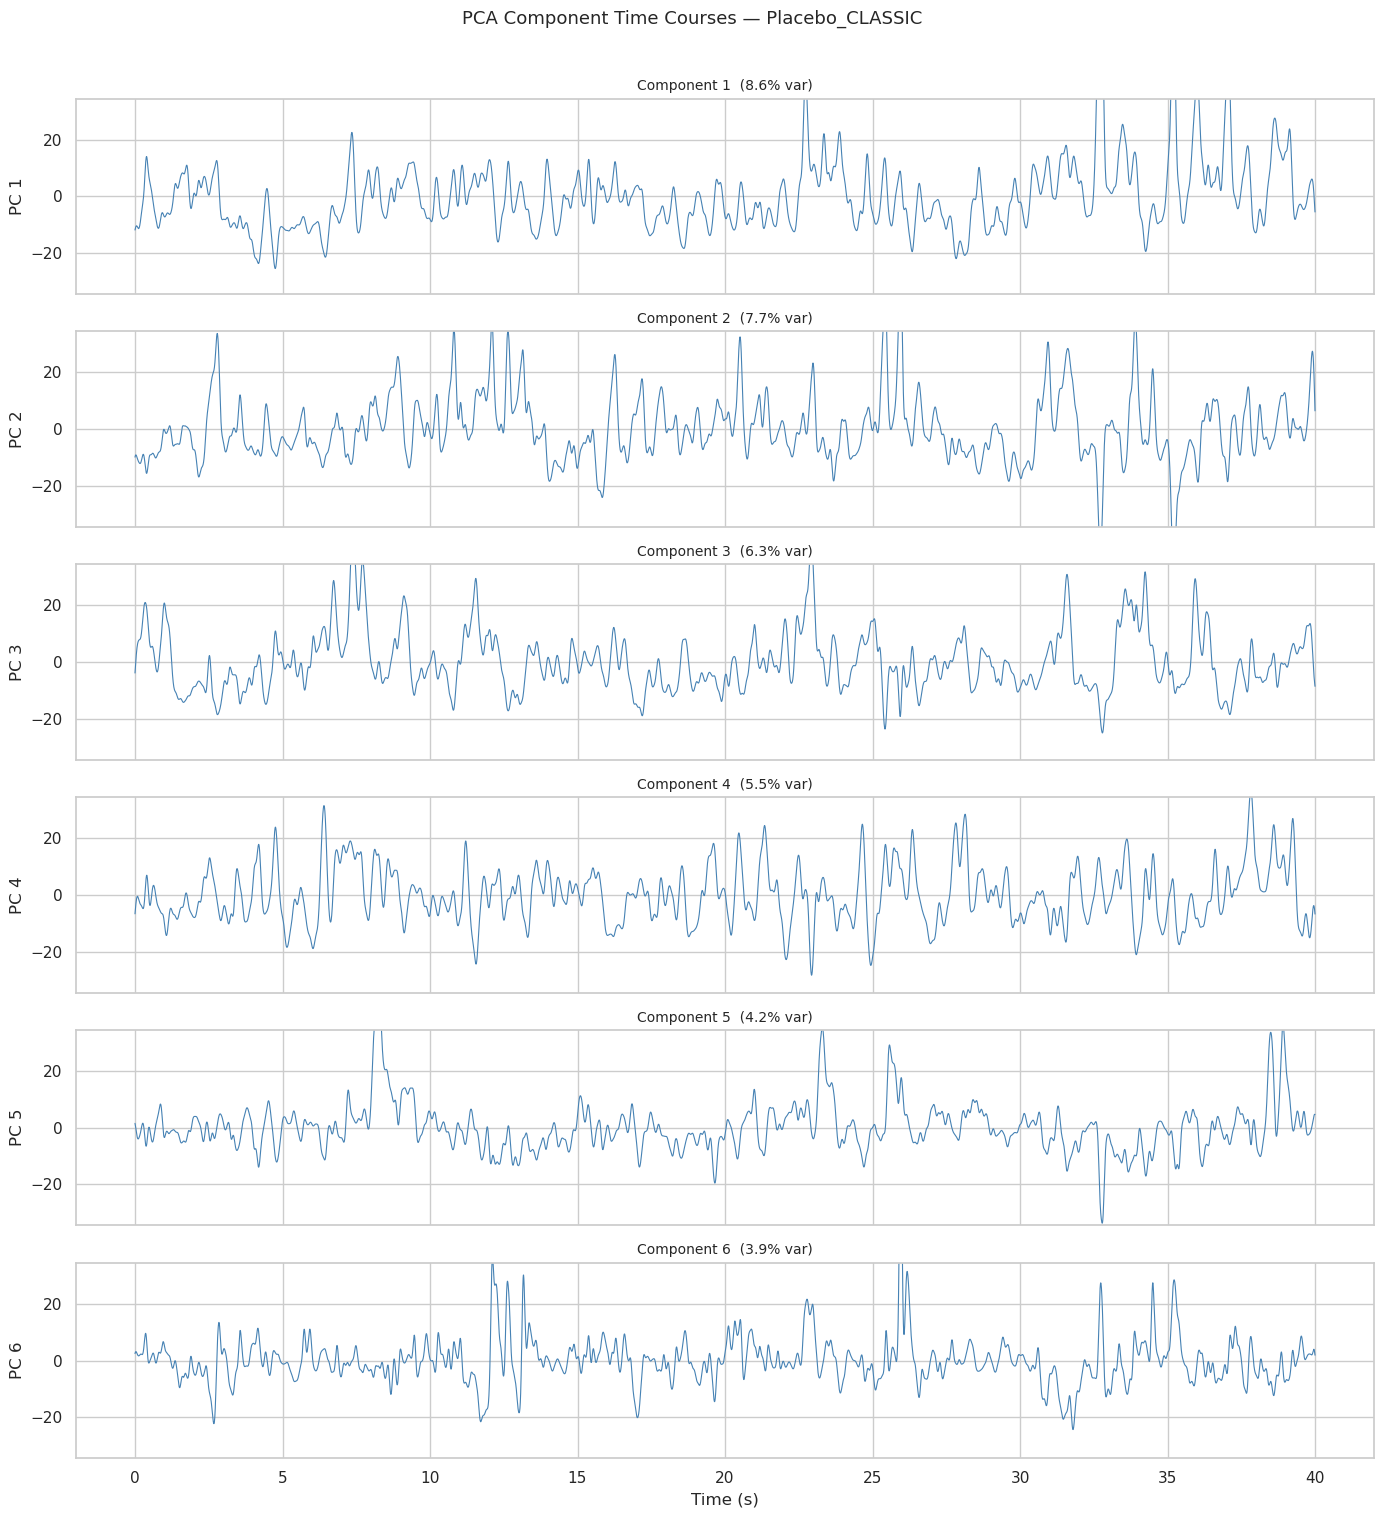

In [ ]:
# PCA scores: (n_times, n_components)
scores = pca.transform(X_super_z.T)  # (T, K)

n_show = min(6, N_COMPONENTS_PCA)
fig, axes = plt.subplots(n_show, 1, figsize=(14, 2.5 * n_show), sharex=True)
_ylim = np.percentile(np.abs(scores[:, :n_show]), 99)
for i, ax in enumerate(axes):
    ax.plot(time, scores[:, i], lw=0.8, color="steelblue")
    ax.set_ylim(-_ylim, _ylim)
    ax.set_ylabel(f"PC {i + 1}")
    ax.set_title(f"Component {i + 1}  ({explained[i] * 100:.1f}% var)", fontsize=10)

axes[-1].set_xlabel("Time (s)")
fig.suptitle(f"PCA Component Time Courses \u2014 {LABEL}", fontsize=13, y=1.01)
fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(PLOTS_DIR / "pca_timecourses.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 3 — Subject Loadings per Component

Each PCA component has a loading vector of length
`n_subjects × n_channels × n_freqs`.  By reshaping back to
`(n_subjects, n_channels, n_freqs)` and averaging over channels and
frequencies, we obtain a **per-subject weight** for each component.

This shows which participants contribute most strongly to each mode.


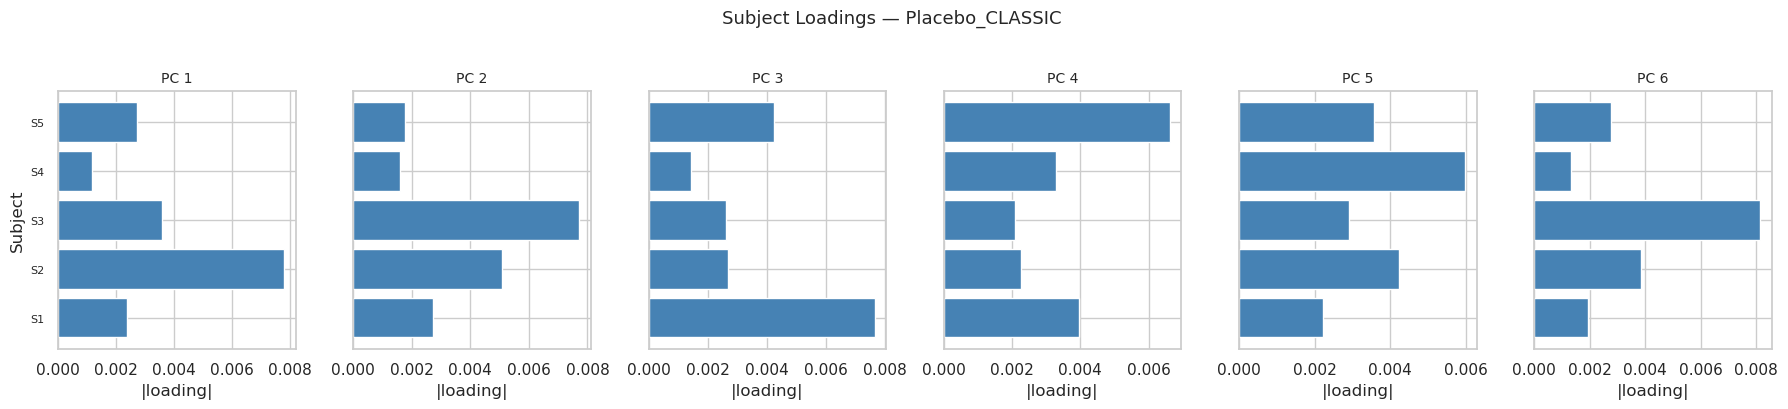

In [ ]:
# PCA components (loadings): (n_components, n_features) = (K, S*C*F)
loadings = pca.components_  # (K, S*C*F)

# Reshape to (K, n_subjects, n_channels, n_freqs)
loadings_4d = loadings.reshape(N_COMPONENTS_PCA, n_subjects, n_channels, n_freqs)

# Subject loadings: mean absolute loading over channels and frequencies
subject_loadings = np.abs(loadings_4d).mean(axis=(2, 3))  # (K, n_subjects)

n_show = min(6, N_COMPONENTS_PCA)
fig, axes = plt.subplots(1, n_show, figsize=(3 * n_show, 4), sharey=True)
for i, ax in enumerate(axes):
    ax.barh(
        range(n_subjects),
        subject_loadings[i],
        color="steelblue",
    )
    ax.set_yticks(range(n_subjects))
    ax.set_yticklabels([f"S{s + 1}" for s in range(n_subjects)], fontsize=8)
    ax.set_xlabel("|loading|")
    ax.set_title(f"PC {i + 1}", fontsize=10)

axes[0].set_ylabel("Subject")
fig.suptitle(f"Subject Loadings \u2014 {LABEL}", fontsize=13, y=1.02)
fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(PLOTS_DIR / "pca_subject_loadings.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 4 — Channel Loadings (Topographic Maps)

Average absolute loadings over subjects and frequencies to get a
per-channel weight for each component.  Plot as a scalp topography
using `mne.viz.plot_topomap`.


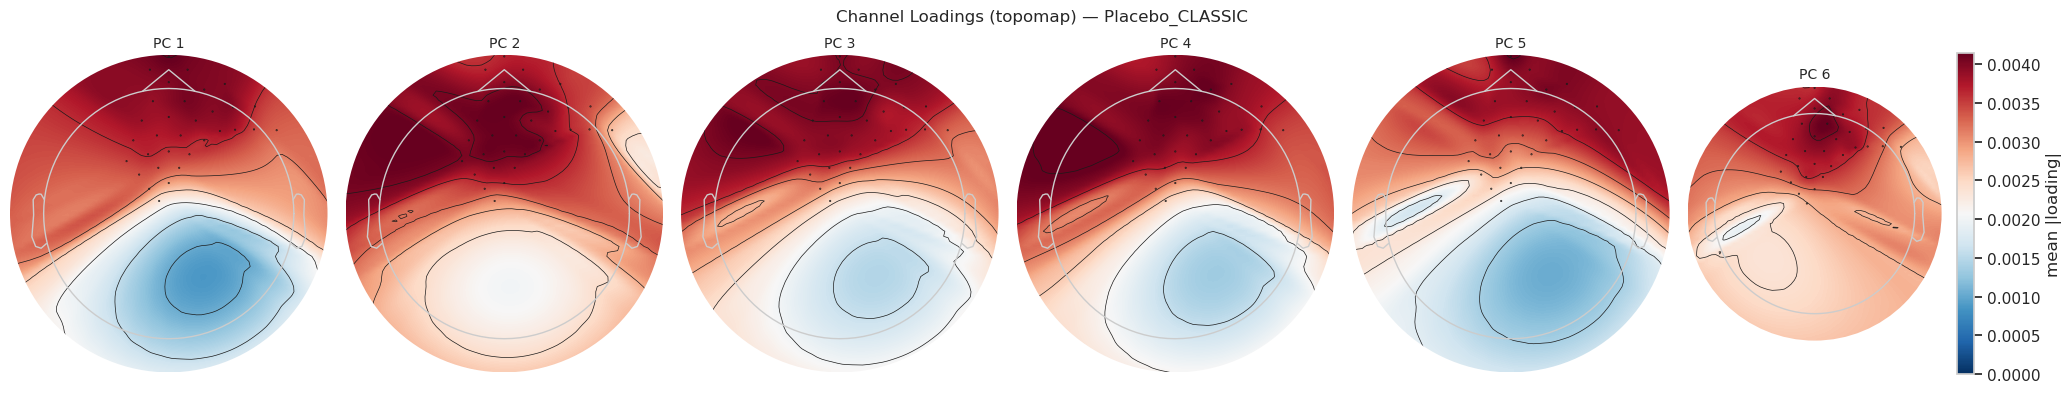

In [ ]:
import mne  # noqa: E402
from mne.viz import plot_topomap  # noqa: E402

# Channel loadings: mean |loading| over subjects and frequencies
channel_loadings = np.abs(loadings_4d).mean(axis=(1, 3))  # (K, n_channels)

# Get MNE Info for topomap
info = analyzers[LABEL].info
info = mne.pick_info(info, mne.pick_types(info, eeg=True))
if n_channels < len(info.ch_names):
    info = mne.pick_info(info, list(range(n_channels)))

n_show = min(6, N_COMPONENTS_PCA)
_vlim = np.percentile(np.abs(channel_loadings[:n_show]), 99)
fig, axes = plt.subplots(1, n_show, figsize=(3.5 * n_show, 4))
for i, ax in enumerate(axes):
    im, _ = plot_topomap(
        channel_loadings[i], info, axes=ax, show=False, cmap="RdBu_r",
        # vmin=-_vlim, vmax=_vlim,
    )
    ax.set_title(f"PC {i + 1}", fontsize=10)

fig.suptitle(f"Channel Loadings (topomap) \u2014 {LABEL}", fontsize=12)
plt.colorbar(im, ax=axes[-1], label="mean |loading|")
fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(PLOTS_DIR / "pca_channel_topomap.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 5 — Frequency Loadings per Component

Average absolute loadings over subjects and channels to get a
per-frequency weight for each component.  This reveals which
frequency bands dominate each temporal mode.


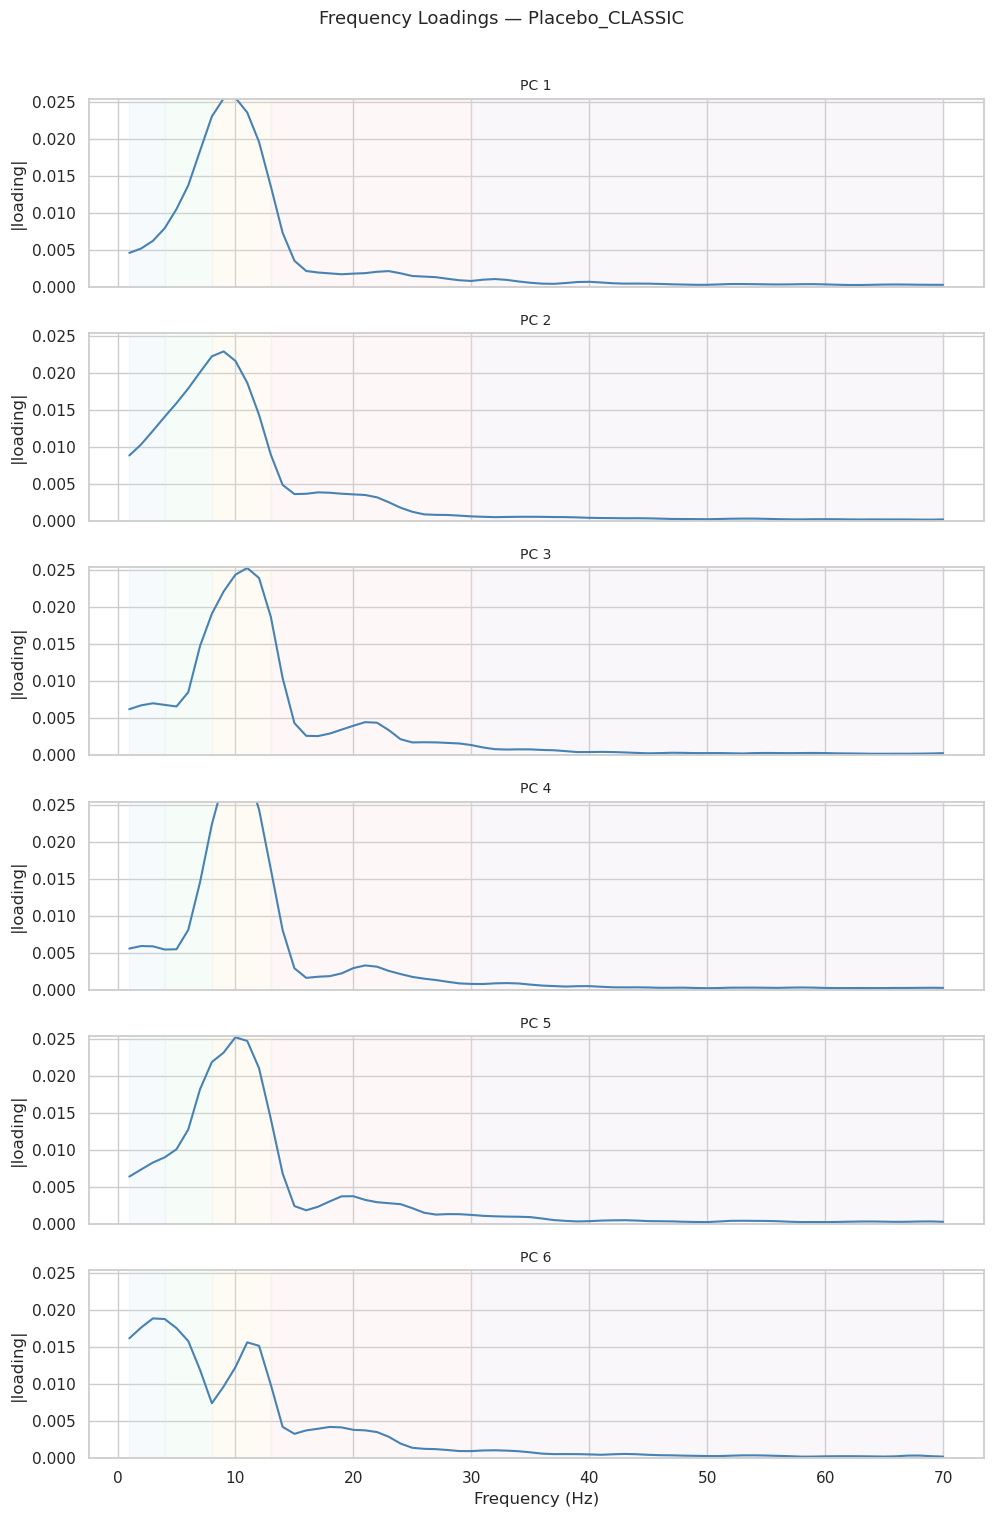

In [ ]:
# Frequency loadings: mean |loading| over subjects and channels
freq_loadings = np.abs(loadings_4d).mean(axis=(1, 2))  # (K, n_freqs)

n_show = min(6, N_COMPONENTS_PCA)
fig, axes = plt.subplots(n_show, 1, figsize=(10, 2.5 * n_show), sharex=True)
if n_show == 1:
    axes = [axes]

band_colors = {
    "delta": "#d4e6f1",
    "theta": "#d5f5e3",
    "alpha": "#fdebd0",
    "beta": "#fadbd8",
    "gamma": "#e8daef",
}

_ymax = np.percentile(freq_loadings[:n_show], 99)
for i, ax in enumerate(axes):
    ax.plot(FREQS, freq_loadings[i], lw=1.5, color="steelblue")
    ax.set_ylim(0, _ymax)
    for band, (lo, hi) in FREQUENCY_BANDS.items():
        ax.axvspan(lo, hi, alpha=0.2, color=band_colors.get(band, "grey"))
    ax.set_ylabel("|loading|")
    ax.set_title(f"PC {i + 1}", fontsize=10)

axes[-1].set_xlabel("Frequency (Hz)")
fig.suptitle(f"Frequency Loadings \u2014 {LABEL}", fontsize=13, y=1.01)
fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(PLOTS_DIR / "pca_freq_loadings.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 6 — Component Power Spectrogram

For each PCA component, compute the short-time Fourier transform (via
Welch's method in sliding windows) of the component time course to
reveal its time–frequency content.  This shows whether a component
has a stable spectral signature or varies over the stimulus.


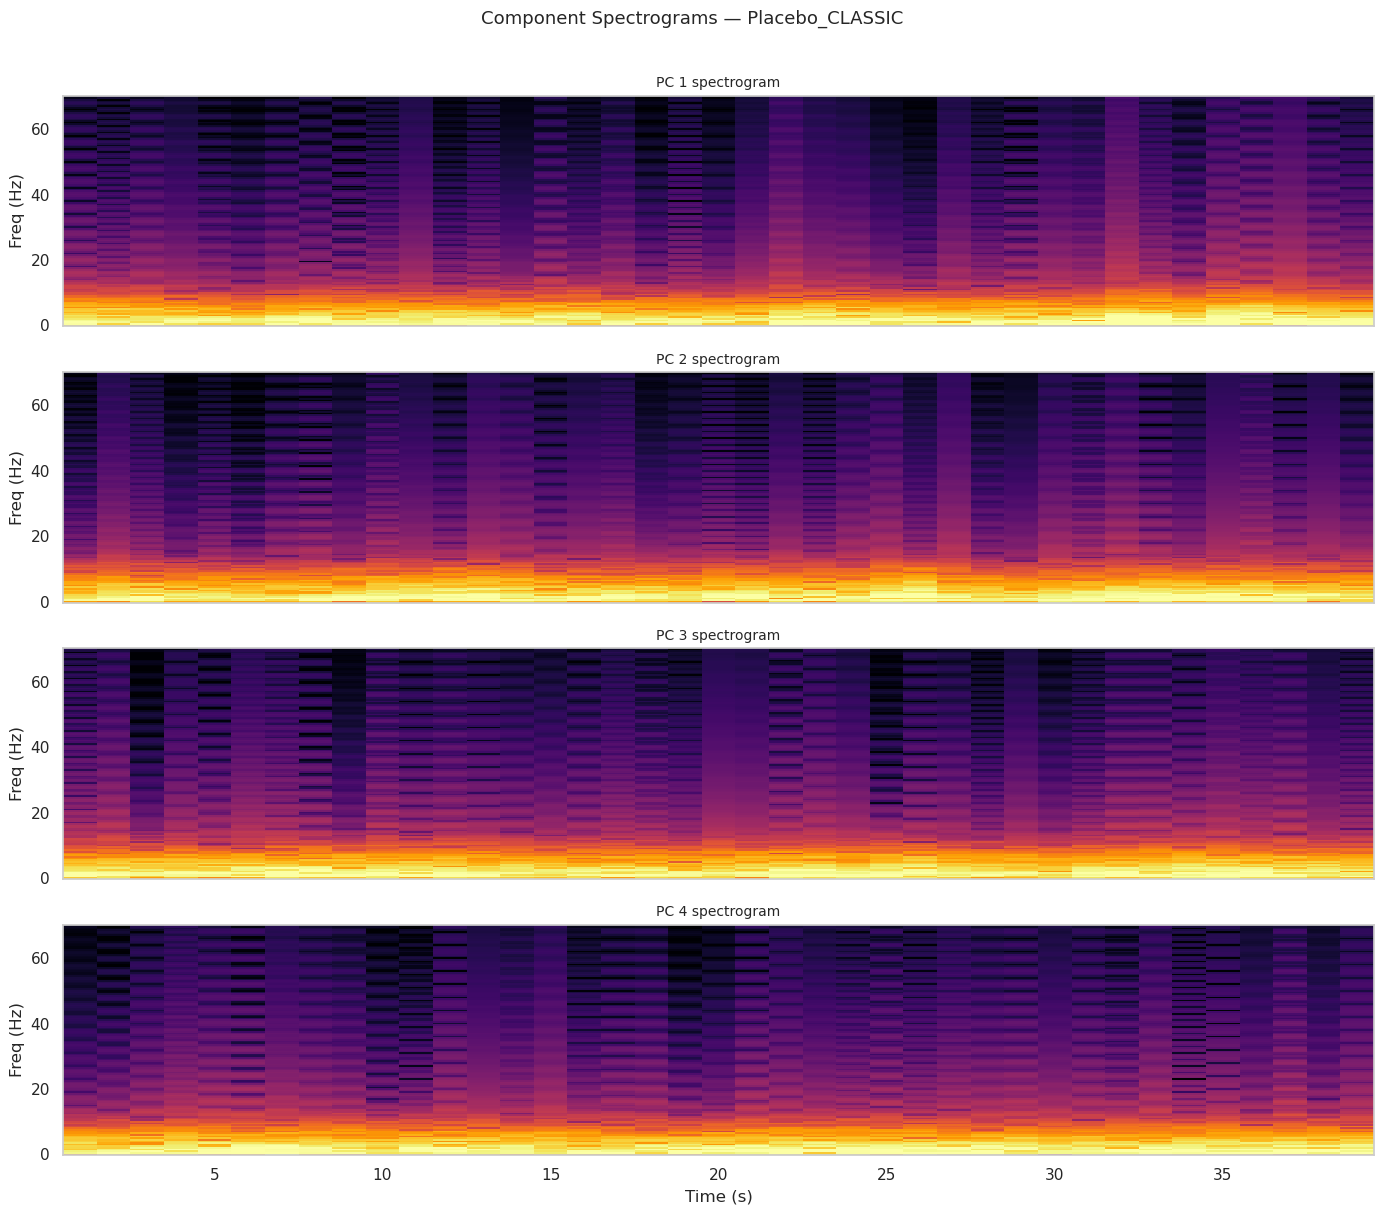

In [ ]:
from scipy.signal import spectrogram as sp_spectrogram  # noqa: E402

n_show = min(4, N_COMPONENTS_PCA)
fig, axes = plt.subplots(n_show, 1, figsize=(14, 3 * n_show), sharex=True)
if n_show == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    f_spec, t_spec, Sxx = sp_spectrogram(
        scores[:, i], fs=sfreq, nperseg=int(sfreq * 2), noverlap=int(sfreq)
    )
    # Limit to the wavelet frequency range
    freq_mask = f_spec <= FREQS[-1]
    _Sxx_db = 10 * np.log10(Sxx[freq_mask] + 1e-12)
    _vmin_s, _vmax_s = np.percentile(_Sxx_db, 1), np.percentile(_Sxx_db, 99)
    ax.pcolormesh(
        t_spec, f_spec[freq_mask], _Sxx_db, cmap="inferno", vmin=_vmin_s, vmax=_vmax_s
    )
    ax.set_ylabel("Freq (Hz)")
    ax.set_title(f"PC {i + 1} spectrogram", fontsize=10)

axes[-1].set_xlabel("Time (s)")
fig.suptitle(f"Component Spectrograms \u2014 {LABEL}", fontsize=13, y=1.01)
fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(PLOTS_DIR / "pca_spectrograms.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 7 — ISC of Component Time Courses

Reconstruct each subject's contribution to each PCA component by
projecting the individual subject data onto the component axes.
Then compute leave-one-out ISC on the resulting per-subject component
activations to test whether a component's time course is shared
across participants.


In [ ]:
# Per-subject projection: for each subject, flatten (n_channels, n_freqs, n_times)
# and project onto PCA axes → (n_subjects, n_components, n_times)
per_subject_scores = np.zeros((n_subjects, N_COMPONENTS_PCA, n_times))
for s in range(n_subjects):
    # Subject data: (n_channels * n_freqs, n_times)
    X_s = bb_data[s].reshape(-1, n_times)
    X_s_z = (
        X_s - row_mean[s * n_channels * n_freqs : (s + 1) * n_channels * n_freqs]
    ) / (row_std[s * n_channels * n_freqs : (s + 1) * n_channels * n_freqs])
    # Project: (n_components, n_channels*n_freqs) @ (n_channels*n_freqs, n_times)
    per_subject_scores[s] = pca.components_ @ X_s_z

print(f"Per-subject scores shape: {per_subject_scores.shape}")

# Compute LOO-ISC on (n_subjects, n_components, n_times)
loo_isc, mean_loo_isc = compute_loo_isc(per_subject_scores)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, N_COMPONENTS_PCA + 1), mean_loo_isc, color="steelblue")
ax.axhline(0, ls="--", color="gray", lw=0.8)
ax.set_xlabel("Component")
ax.set_ylabel("Mean LOO-ISC")
ax.set_title(f"ISC of PCA Component Time Courses \u2014 {LABEL}")

fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(PLOTS_DIR / "pca_component_isc.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nComponent ISC (sorted by mean ISC):")
for idx in np.argsort(mean_loo_isc)[::-1]:
    print(f"  PC {idx + 1:2d}:  ISC = {mean_loo_isc[idx]:.4f}")

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2240 is different from 11200)

---
## 8 — Cross-Component Correlation Matrix

After PCA, components are orthogonal by construction.  However, ICA
components may have residual correlations.  Compute the Pearson
correlation between all pairs of component time courses to verify
independence and identify any residual structure.

We compare PCA and FastICA side by side.


In [ ]:
# Fit FastICA on PCA-reduced data for comparison
ica = FastICA(
    n_components=N_COMPONENTS_ICA,
    random_state=ICA_RANDOM_STATE,
    max_iter=500,
    whiten="unit-variance",
)
ica_scores = ica.fit_transform(X_super_z.T)  # (T, K_ica)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel A: PCA correlation
pca_corr = np.corrcoef(scores.T)
im0 = axes[0].imshow(pca_corr, vmin=-1, vmax=1, cmap="RdBu_r")
axes[0].set_title("PCA component correlations")
axes[0].set_xlabel("Component")
axes[0].set_ylabel("Component")
plt.colorbar(im0, ax=axes[0], shrink=0.8)

# Panel B: ICA correlation
ica_corr = np.corrcoef(ica_scores.T)
im1 = axes[1].imshow(ica_corr, vmin=-1, vmax=1, cmap="RdBu_r")
axes[1].set_title("ICA component correlations")
axes[1].set_xlabel("Component")
axes[1].set_ylabel("Component")
plt.colorbar(im1, ax=axes[1], shrink=0.8)

fig.suptitle(f"Cross-Component Correlations \u2014 {LABEL}", fontsize=13, y=1.01)
fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(
        PLOTS_DIR / "cross_component_correlation.png", dpi=150, bbox_inches="tight"
    )
plt.show()

---
## 8.1 — ICA Component Time Courses

Plot the FastICA component time courses side by side with PCA for
qualitative comparison.  ICA components should be more
"spiky" / non-Gaussian than PCA components.


In [ ]:
n_show = min(6, N_COMPONENTS_ICA)
_ylim_ica = np.percentile(np.abs(ica_scores[:, :n_show]), 99)
fig, axes = plt.subplots(n_show, 1, figsize=(14, 2.5 * n_show), sharex=True)
if n_show == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    ax.plot(time, ica_scores[:, i], lw=0.8, color="darkorange")
    ax.set_ylim(-_ylim_ica, _ylim_ica)
    ax.set_ylabel(f"IC {i + 1}")
    ax.set_title(f"ICA Component {i + 1}", fontsize=10)

axes[-1].set_xlabel("Time (s)")
fig.suptitle(f"ICA Component Time Courses \u2014 {LABEL}", fontsize=13, y=1.01)
fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(PLOTS_DIR / "ica_timecourses.png", dpi=150, bbox_inches="tight")
plt.show()

NameError: name 'ica_scores' is not defined

---
## 8.2 — ICA Topographic Maps — Mean Loading Across Subjects

The ICA mixing matrix has shape `(S×C×F, K_ica)`.  Reshape to
`(S, C, F, K)`, average over frequencies to get per-(subject, channel)
loadings, then average over subjects for the **mean channel loading**
per component.  Plot as scalp topographies.


In [ ]:
# ICA mixing: (S*C*F, K_ica)
ica_mixing = ica.mixing_  # (S*C*F, K_ica)

# Reshape to (S, C, F, K)
ica_mixing_4d = ica_mixing.reshape(
    n_subjects, n_channels, n_freqs, N_COMPONENTS_ICA
)

# Average over frequencies → (S, C, K)
ica_channel_loadings = ica_mixing_4d.mean(axis=2)

# Mean across subjects → (C, K)
ica_ch_mean = ica_channel_loadings.mean(axis=0)  # (C, K)

n_show = min(6, N_COMPONENTS_ICA)
_vlim_mean = np.percentile(np.abs(ica_ch_mean[:, :n_show]), 99)
fig, axes = plt.subplots(1, n_show, figsize=(3.5 * n_show, 4))
if n_show == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    im, _ = plot_topomap(
        ica_ch_mean[:, i],
        info,
        axes=ax,
        show=False,
        cmap="RdBu_r",
        vmin=-_vlim_mean,
        vmax=_vlim_mean,
    )
    ax.set_title(f"IC {i + 1}", fontsize=10)

fig.suptitle(
    f"ICA Topomaps — Mean Loading Across Subjects — {LABEL}",
    fontsize=12,
)
plt.colorbar(im, ax=axes[-1], label="mean loading")
fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(
        PLOTS_DIR / "ica_topomap_mean.png",
        dpi=150,
        bbox_inches="tight",
    )
plt.show()


NameError: name 'ica' is not defined

---
## 8.3 — ICA Topographic Maps — Variance Across Subjects

Compute the **variance** of each channel's ICA loading across subjects.
High variance indicates the component has different strength at that
electrode across individuals.  Low variance means consistent activation.


In [ ]:
# Variance across subjects → (C, K)
ica_ch_var = ica_channel_loadings.var(axis=0)  # (C, K)

n_show = min(6, N_COMPONENTS_ICA)
_vmax_var = np.percentile(ica_ch_var[:, :n_show], 99)
fig, axes = plt.subplots(1, n_show, figsize=(3.5 * n_show, 4))
if n_show == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    im, _ = plot_topomap(
        ica_ch_var[:, i],
        info,
        axes=ax,
        show=False,
        cmap="YlOrRd",
        vmin=0,
        vmax=_vmax_var,
    )
    ax.set_title(f"IC {i + 1}", fontsize=10)

fig.suptitle(
    f"ICA Topomaps — Variance Across Subjects — {LABEL}",
    fontsize=12,
)
plt.colorbar(im, ax=axes[-1], label="variance of loading")
fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(
        PLOTS_DIR / "ica_topomap_variance.png",
        dpi=150,
        bbox_inches="tight",
    )
plt.show()


NameError: name 'ica_channel_loadings' is not defined

---
## 8.4 — Inter-Individual IC Correlations

For each ICA component, compute the Pearson correlation between every
pair of subjects using their channel loading vectors (freq-averaged).
High correlations indicate the IC has a consistent spatial distribution
across individuals — a hallmark of stimulus-driven components.


In [ ]:
# ica_channel_loadings: (S, C, K) — per-subject, per-channel IC loading
n_show = min(6, N_COMPONENTS_ICA)
fig, axes = plt.subplots(
    1, n_show, figsize=(3.5 * n_show, 3.5), constrained_layout=True
)
if n_show == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    # Each subject's channel-loading vector for IC i: (n_channels,)
    corr_mat = np.corrcoef(ica_channel_loadings[:, :, i])  # (S, S)
    im = ax.imshow(corr_mat, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(n_subjects))
    ax.set_yticks(range(n_subjects))
    ax.set_xticklabels(
        [f"S{s + 1}" for s in range(n_subjects)], fontsize=7
    )
    ax.set_yticklabels(
        [f"S{s + 1}" for s in range(n_subjects)], fontsize=7
    )
    ax.set_title(f"IC {i + 1}", fontsize=10)

fig.suptitle(
    f"Inter-Individual IC Correlations (channel loadings) — {LABEL}",
    fontsize=12,
)
plt.colorbar(im, ax=axes[-1], label="Pearson r", shrink=0.8)
if SAVE_PLOTS:
    fig.savefig(
        PLOTS_DIR / "ica_interindividual_correlation.png",
        dpi=150,
        bbox_inches="tight",
    )
plt.show()


---
## Summary

Available variables for further analysis:

| Variable | Shape | Description |
|----------|-------|-------------|
| `X_super_z` | `(S×C×F, T)` | Z-scored super-brain matrix |
| `pca` | — | Fitted PCA object |
| `scores` | `(T, K)` | PCA component time courses |
| `loadings_4d` | `(K, S, C, F)` | PCA loadings reshaped to 4-D |
| `per_subject_scores` | `(S, K, T)` | Per-subject PCA scores |
| `ica` | — | Fitted FastICA object |
| `ica_scores` | `(T, K_ica)` | ICA component time courses |

**Analyses implemented:**

1. PCA scree plot (variance explained)
2. Component time courses
3. Subject loadings per component
4. Channel loadings — topographic maps
5. Frequency loadings per component
6. Component power spectrogram (STFT of component time course)
7. ISC of PCA component time courses
8. Cross-component correlation (PCA vs ICA)

See `README.md` in this directory for the full analysis rationale,
alternative decomposition strategies, and ideas for future extensions.
